# Ropedia Academy — C8 · Task structure & intention modeling

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChaoYue0307/ropedia-academy/blob/main/notebooks/C8.ipynb)

> **Models the task as a partial-order action grammar and goal inference, drawing the precedence graph and the goal posterior bar chart.**
>
> 把任务建模为偏序动作语法与目标推断，画出先后关系图与目标后验柱状图。

This is the lesson's core example — **self-contained and runnable end to end**. It builds toy tensors, performs the lesson's key computation, and **visualizes the result with matplotlib** (the plot renders inline below the cell), so you learn the concept by executing and *seeing* it.

Colab's default runtime already includes `torch`, `numpy`, `networkx`, and `matplotlib`, so just press **Run all** — every cell goes green and a figure appears. Sizes are shrunk to run on CPU; swap in a real batch and the same code scales up.

🔗 Full lesson (with the interactive demo & key terms): https://chaoyue0307.github.io/ropedia-academy/lesson/C8

after {'grind'} valid next: ['add_water', 'add_milk'] | inferred goal: latte


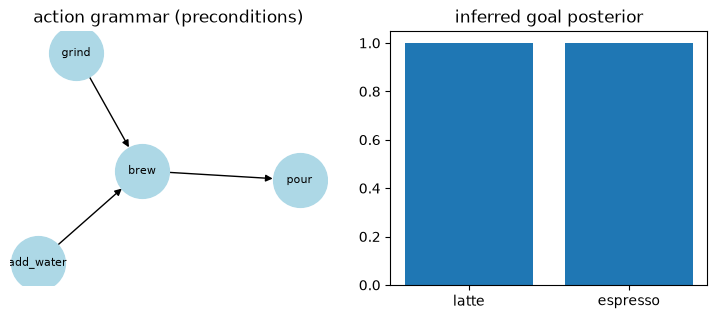

In [1]:
import networkx as nx, matplotlib.pyplot as plt
# Task structure: a partial-order action grammar + goal inference.

# ---------- INPUT: action set, preconditions, candidate goals, observed steps ----------
actions = ["grind", "add_water", "brew", "pour", "add_milk"]
precede = {"brew": {"grind","add_water"}, "pour": {"brew"}}
goals = {"latte": ["grind","add_water","brew","pour","add_milk"],
         "espresso": ["grind","add_water","brew","pour"]}
observed = ["grind","add_water","brew"]

# ---------- MODEL: valid-next via preconditions + a goal posterior ----------
valid_next = lambda done: [a for a in actions if a not in done and precede.get(a,set()) <= done]
post = {g: sum(a in s for a in observed)/len(observed) for g, s in goals.items()}

# ---------- OUTPUT: inferences + the grammar graph and the goal posterior ----------
print("after {'grind'} valid next:", valid_next({"grind"}), "| inferred goal:", max(post, key=post.get))
G = nx.DiGraph()
for a, deps in precede.items():
    for d in deps: G.add_edge(d, a)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.3))
nx.draw(G, nx.spring_layout(G, seed=1), with_labels=True, ax=ax[0],
        node_color='lightblue', node_size=1500, font_size=8)
ax[0].set_title("action grammar (preconditions)")
ax[1].bar(post.keys(), post.values()); ax[1].set_title("inferred goal posterior"); plt.show()

### Where to go next

- Swap the toy tensors for a real batch and watch the shapes flow through.
- Open the matching lesson for the math and an interactive figure: https://chaoyue0307.github.io/ropedia-academy/lesson/C8
- Browse every notebook: https://github.com/ChaoYue0307/ropedia-academy/tree/main/notebooks